### PART 2 — Descriptor Calculation & Exploratory Data Analysis

#### In this part we will:

#### 1- Convert SMILES → RDKit molecules

#### 2- Calculate basic molecular descriptors

#### 3- Generate Morgan fingerprints

#### 4- Perform exploratory data analysis (EDA)

In [8]:
# importing the library

from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Converting Smiles to Molecules

df = pd.read_csv("cox2_clean.csv")

df['mol'] = df['canonical_smiles'].apply(Chem.MolFromSmiles)

In [3]:
# Calculating Basic Molecular Descriptors

df['MolWt'] = df['mol'].apply(Descriptors.MolWt)
df['LogP'] = df['mol'].apply(Descriptors.MolLogP)
df['HDonors'] = df['mol'].apply(Descriptors.NumHDonors)
df['HAcceptors'] = df['mol'].apply(Descriptors.NumHAcceptors)
df['TPSA'] = df['mol'].apply(Descriptors.TPSA)

df.head()

,molecule_chembl_id,canonical_smiles,standard_value,standard_units,pIC50,mol,MolWt,LogP,HDonors,HAcceptors,TPSA
0,CHEMBL297008,Cc1ccc(-c2ccc(S(C)(=O)=O)cc2)n1-c1ccccc1,60.00,nM,7.221849,<rdkit.Chem.rdchem.Mol object at 0x000001624A6...,311.406,3.85622,0,2,39.07
1,CHEMBL289813,Cc1c(C=O)cc(-c2ccc(S(C)(=O)=O)cc2)n1-c1ccc(F)cc1,3230.00,nM,5.490797,<rdkit.Chem.rdchem.Mol object at 0x000001624A6...,357.406,3.80782,0,3,56.14
2,CHEMBL43736,Cc1c(COc2cccc(Cl)c2)cc(-c2ccc(S(C)(=O)=O)cc2)n...,80.00,nM,7.096910,<rdkit.Chem.rdchem.Mol object at 0x000001624A6...,469.965,6.22772,0,3,48.30
3,CHEMBL140167,Fc1ccc(-c2[nH]c(-c3ccc(F)cc3)c3c2C2CCC3CC2)cc1,0.12,nM,9.920819,<rdkit.Chem.rdchem.Mol object at 0x000001624A6...,335.397,6.38170,1,0,15.79
4,CHEMBL44194,CCc1ccc(-c2ccc(S(C)(=O)=O)cc2)n1-c1ccc(F)cc1,100000.00,nM,4.000000,<rdkit.Chem.rdchem.Mol object at 0x000001624A6...,343.423,4.24930,0,2,39.07


### Exploratory Data Analysis



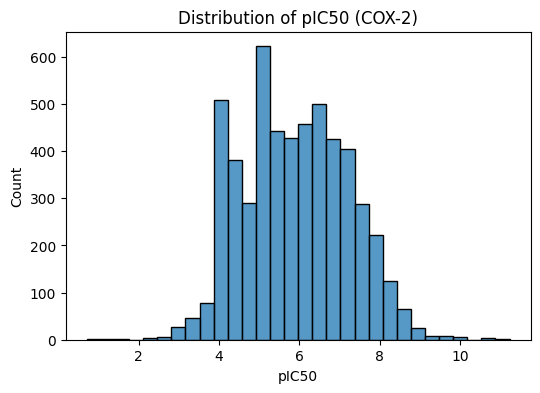

In [4]:
# Distribution of pIC50

plt.figure(figsize=(6,4))
sns.histplot(df['pIC50'], bins=30)
plt.title("Distribution of pIC50 (COX-2)")
plt.show()

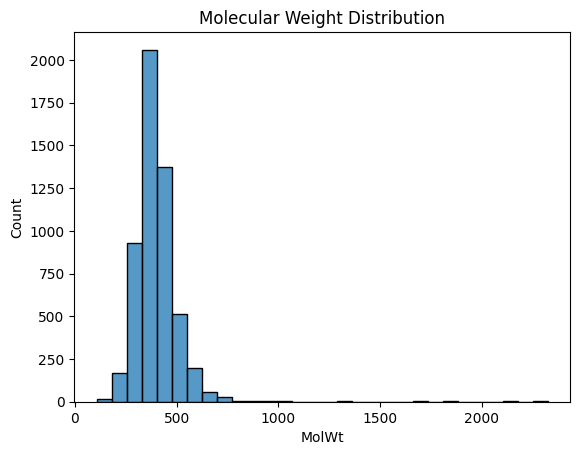

In [6]:
# Distribution of molecular weight

sns.histplot(df['MolWt'], bins=30)
plt.title("Molecular Weight Distribution")
plt.show()

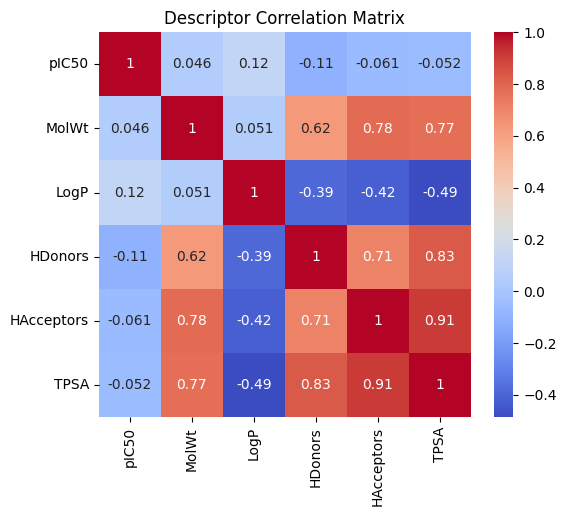

In [7]:
# Correlation Matrix
corr = df[['pIC50','MolWt','LogP','HDonors','HAcceptors','TPSA']].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Descriptor Correlation Matrix")
plt.show()

In [10]:
# Generate morgan fingerprints


from rdkit.Chem import rdFingerprintGenerator

# 1. On crée le générateur
fp_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

# 2. Fonction simplifiée
def mol_to_fp(mol):
    if mol is not None:
        return fp_gen.GetFingerprintAsNumPy(mol)
    return np.zeros((2048,))

# 3. Application
fps = df['mol'].apply(mol_to_fp)
X_fp = np.stack(fps.values)
y = df['pIC50'].values

print("Fingerprint shape:", X_fp.shape)


Fingerprint shape: (5377, 2048)


In [15]:
import os

np.save("X_fp.npy", X_fp)
np.save("y.npy", y)

In [16]:
df.to_csv("cox2_with_descriptors.csv", index=False)

### PART 3 — Dataset Preparation for Modeling

#### In this part we will:

#### Prepare feature sets

#### Combine fingerprints + descriptors

#### Split train/test properly

#### Scale descriptors (if needed)

#### Prevent data leakage

In [18]:
# Prepare Descriptor Matrix

desc_cols = ['MolWt','LogP','HDonors','HAcceptors','TPSA']

X_desc = df[desc_cols].values
y = df['pIC50'].values

print("Descriptor shape:", X_desc.shape)

Descriptor shape: (5377, 5)


In [20]:
# Combining Fingerprints + Descriptors

X_combined = np.concatenate([X_fp, X_desc], axis=1)

print("Combined shape:", X_combined.shape)

Combined shape: (5377, 2053)


In [21]:
# Train/Test Split

from sklearn.model_selection import train_test_split

X_train_fp, X_test_fp, y_train, y_test = train_test_split(
    X_fp, y, test_size=0.2, random_state=42)

X_train_desc, X_test_desc, _, _ = train_test_split(
    X_desc, y, test_size=0.2, random_state=42)

X_train_comb, X_test_comb, _, _ = train_test_split(
    X_combined, y, test_size=0.2, random_state=42)

print("Training size:", X_train_fp.shape[0])
print("Testing size:", X_test_fp.shape[0])


Training size: 4301
Testing size: 1076


In [24]:
# Scaling Descriptor Data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_desc_scaled = scaler.fit_transform(X_train_desc)
X_test_desc_scaled = scaler.transform(X_test_desc)

In [25]:
# saving the data

np.save("X_train_fp.npy", X_train_fp)
np.save("X_test_fp.npy", X_test_fp)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)